## Exploratory data analysis

Imports

In [3]:
import pandas as pd

Load the data

In [4]:
movies = pd.read_csv("./data/movies.csv")
tags = pd.read_csv("./data/tags.csv")
ratings = pd.read_csv("./data/ratings.csv")

<u>movies.csv</u>

In [5]:
movies.describe()

,movieId
count,86537.000000
mean,155932.817096
std,78037.145347
min,1.000000
25%,111443.000000
50%,164574.000000
75%,211225.000000
max,288983.000000


In [13]:
movies["genres"].value_counts().head(10)

genres
Drama                   12246
Documentary              8064
Comedy                   7689
(no genres listed)       7060
Comedy|Drama             3196
Drama|Romance            2788
Horror                   2467
Comedy|Romance           2176
Thriller                 1397
Comedy|Drama|Romance     1310
Name: count, dtype: int64

In [18]:
genre_counts = movies["genres"].str.get_dummies(sep="|").sum().sort_values(ascending=False)
genre_counts

Drama                 33681
Comedy                22830
Thriller              11675
Romance               10172
Action                 9563
Documentary            9283
Horror                 8570
(no genres listed)     7060
Crime                  6917
Adventure              5349
Sci-Fi                 4850
Animation              4579
Children               4367
Mystery                3972
Fantasy                3821
War                    2301
Western                1690
Musical                1059
Film-Noir               354
IMAX                    195
dtype: int64

There are 20 genres listed (including <code>(no genres listed)</code>). Each movie can have multiple genres and the genres are unevenly distributed.

### <u>ratings.csv</u>

This is a very large dataset with over 30 million rows

In [23]:
ratings["rating"].describe()

count    3.383216e+07
mean     3.542540e+00
std      1.063959e+00
min      5.000000e-01
25%      3.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

Ratings are between ~0.5 and 5 and their distribution is skewed towards higher ratings.

<Axes: >

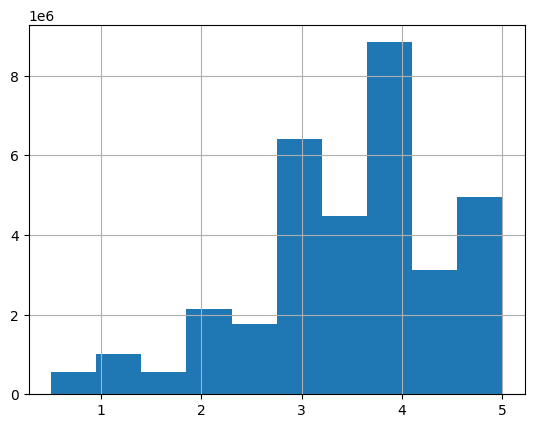

In [24]:
ratings["rating"].hist()

* Ratings are bounded and discrete, so scaling is not strictly necessary.
* Due to dataset size, full matrix-based approaches would be computationally expensive.
* It would be better to use ratings for aggregation rather than full modelling.

### <u>tags.csv</u>

In [25]:
tags["tag"].value_counts().head(20)

tag
sci-fi                14319
atmospheric           12172
action                10683
comedy                10161
surreal                9142
funny                  9094
visually appealing     8890
twist ending           8325
thought-provoking      7727
dark comedy            7659
based on a book        7584
dystopia               6975
cinematography         6473
social commentary      6369
romance                6338
violence               6300
stylized               6163
psychology             6111
fantasy                6082
murder                 5955
Name: count, dtype: int64

Tags are free text, of variable length. They are potentially noisy, but informative, at the same time.

* Tags are unstructured text data, making them suitable for NLP techniques
* TF-IDF could be used to transform tags into numerical features.